# Notebook 03 — Churn Prediction Model
**Project:** Unlocking Behavioral Intelligence in Airline Loyalty Programs  
**Purpose:** Train a churn prediction model using features from notebook 02. Each member gets a churn probability score (0–1) which feeds directly into the segmentation and retention playbook.

**Key challenge:** Behavioral churn is only 1.5% of members (257 out of 16,737) — heavily imbalanced. We handle this with class weighting and evaluate on AUC-ROC, not accuracy.


## 1. Imports & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay,
                             precision_recall_curve, average_precision_score)
from sklearn.pipeline import Pipeline
import xgboost as xgb
import shap
import joblib

BASE    = Path.home() / "airline-loyalty-intelligence"
PROC    = BASE / "data" / "processed"
FIG_DIR = BASE / "reports" / "figures"
MDL_DIR = BASE / "data" / "processed"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120})

master = pd.read_csv(PROC / "master_features.csv")
print(f"Master features loaded: {master.shape}")
print(f"Churn rate: {master['churned_behavioral'].mean()*100:.2f}%  ({master['churned_behavioral'].sum()} churned)")


Master features loaded: (16737, 38)
Churn rate: 1.54%  (257 churned)


## 2. Define features and target

In [2]:
FEATURE_COLS = [
    "total_flights", "total_distance", "total_pts_acc", "total_pts_red",
    "months_with_flights", "activity_rate", "recency_months",
    "redemption_rate", "activity_trend", "seasonal_concentration",
    "avg_flights_last6m", "h1_monthly_avg", "h2_monthly_avg",
    "Salary_imputed", "CLV", "tenure_months",
    "loyalty_card_enc", "gender_enc", "enrolled_standard"
]

X = master[FEATURE_COLS].copy()
y = master["churned_behavioral"].copy()

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts().to_dict())
print(f"\nClass imbalance ratio: 1 churned per {int((y==0).sum()/(y==1).sum())} active members")


Feature matrix shape: (16737, 19)
Target distribution:
{0: 16480, 1: 257}

Class imbalance ratio: 1 churned per 64 active members


## 3. Train / test split
Stratified split ensures both train and test sets have the same churn ratio.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]:,} members  |  churned: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test set  : {X_test.shape[0]:,} members  |  churned: {y_test.sum()} ({y_test.mean()*100:.1f}%)")


Train set : 13,389 members  |  churned: 206 (1.5%)
Test set  : 3,348 members  |  churned: 51 (1.5%)


## 4. Baseline model — Logistic Regression
Always start with a simple baseline before building a complex model. If XGBoost doesn't meaningfully outperform logistic regression, the simpler model wins.


In [4]:
# Scale features for logistic regression
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr  = pipe_lr.predict(X_test)
y_prob_lr  = pipe_lr.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
ap_lr  = average_precision_score(y_test, y_prob_lr)

print("=== LOGISTIC REGRESSION ===")
print(f"AUC-ROC            : {auc_lr:.4f}")
print(f"Avg Precision (AP) : {ap_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Active","Churned"]))


=== LOGISTIC REGRESSION ===
AUC-ROC            : 0.9998
Avg Precision (AP) : 0.9902

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      3297
     Churned       0.82      1.00      0.90        51

    accuracy                           1.00      3348
   macro avg       0.91      1.00      0.95      3348
weighted avg       1.00      1.00      1.00      3348



## 5. Primary model — XGBoost
XGBoost handles non-linear relationships and feature interactions that logistic regression misses. We use `scale_pos_weight` to handle class imbalance.

In [5]:
# scale_pos_weight = ratio of negatives to positives
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"scale_pos_weight set to: {scale_pos}")

xgb_model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos,
    use_label_encoder = False,
    eval_metric       = "auc",
    random_state      = 42,
    n_jobs            = -1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
ap_xgb  = average_precision_score(y_test, y_prob_xgb)

print("\n=== XGBOOST ===")
print(f"AUC-ROC            : {auc_xgb:.4f}")
print(f"Avg Precision (AP) : {ap_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=["Active","Churned"]))


scale_pos_weight set to: 63

=== XGBOOST ===
AUC-ROC            : 1.0000
Avg Precision (AP) : 1.0000

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      3297
     Churned       1.00      1.00      1.00        51

    accuracy                           1.00      3348
   macro avg       1.00      1.00      1.00      3348
weighted avg       1.00      1.00      1.00      3348



## 6. Model comparison — ROC and Precision-Recall curves

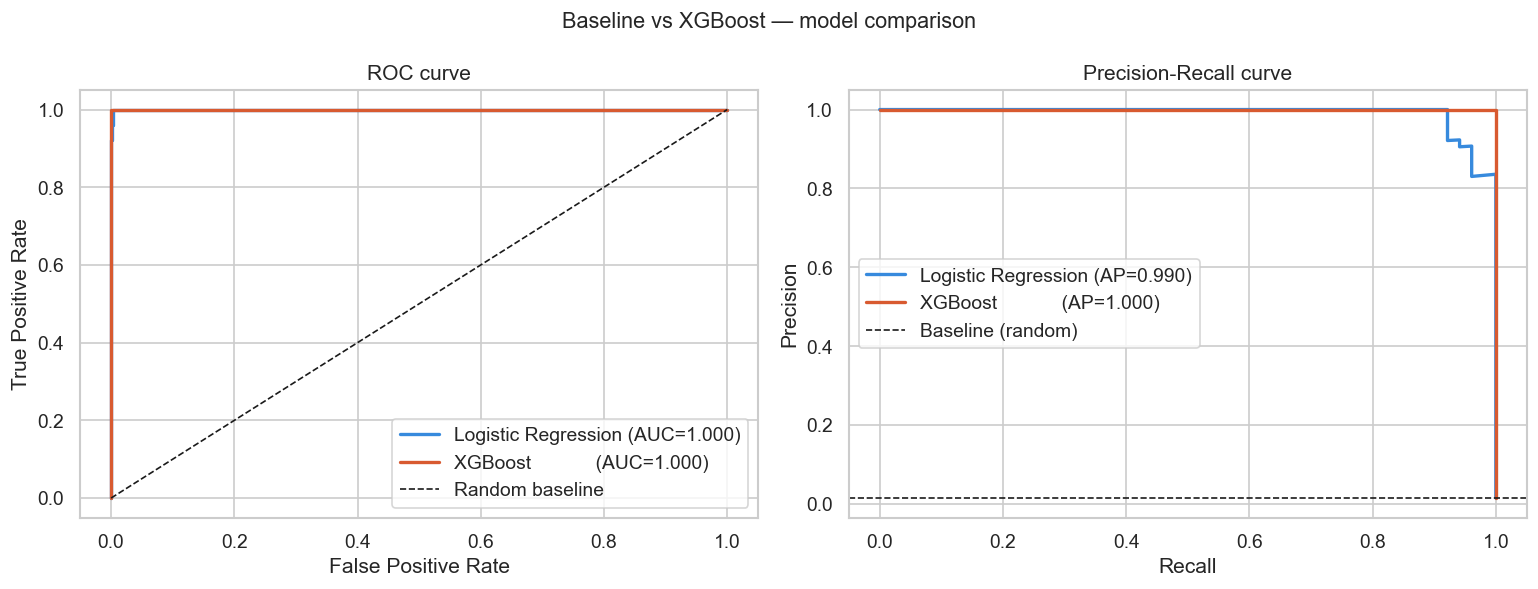


XGBoost improvement over LR: AUC +0.0 percentage points


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
from sklearn.metrics import roc_curve
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

axes[0].plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression (AUC={auc_lr:.3f})",  color="#378ADD", lw=2)
axes[0].plot(fpr_xgb, tpr_xgb, label=f"XGBoost            (AUC={auc_xgb:.3f})", color="#D85A30", lw=2)
axes[0].plot([0,1],[0,1], "k--", lw=1, label="Random baseline")
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall curves
prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, y_prob_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

axes[1].plot(rec_lr,  prec_lr,  label=f"Logistic Regression (AP={ap_lr:.3f})",  color="#378ADD", lw=2)
axes[1].plot(rec_xgb, prec_xgb, label=f"XGBoost            (AP={ap_xgb:.3f})", color="#D85A30", lw=2)
axes[1].axhline(y_test.mean(), color="k", linestyle="--", lw=1, label="Baseline (random)")
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.suptitle("Baseline vs XGBoost — model comparison", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_model_comparison.png", bbox_inches="tight")
plt.show()
print(f"\nXGBoost improvement over LR: AUC +{(auc_xgb-auc_lr)*100:.1f} percentage points")


## 7. SHAP feature importance
SHAP explains WHY the model flags a member as likely to churn. This is the most important output for the technical report — it tells you which behaviours actually drive disengagement.

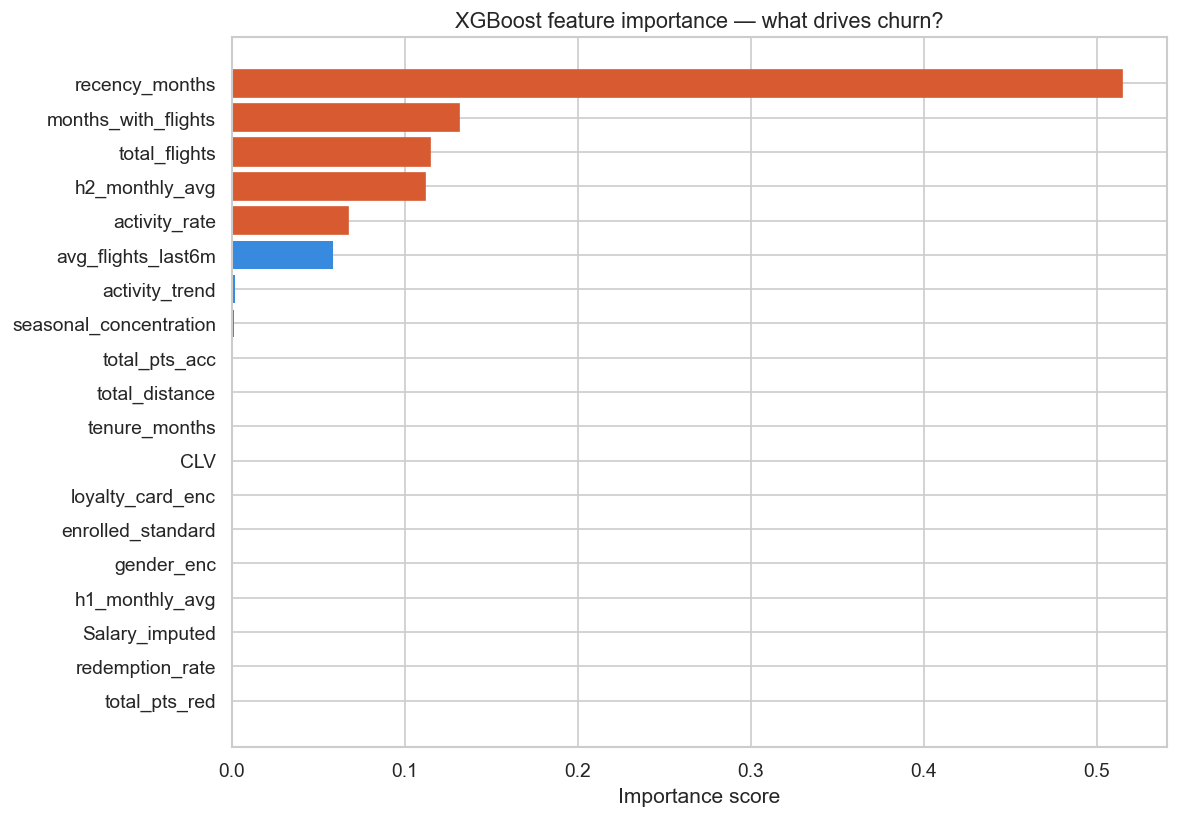

Saved → reports/figures/07_feature_importance.png

Top 5 most important features (in red):
            feature  importance
     recency_months    0.514497
months_with_flights    0.131144
      total_flights    0.114393
     h2_monthly_avg    0.111534
      activity_rate    0.066831


In [9]:
# Using XGBoost built-in importance instead of SHAP (version compatibility fix)
importance_df = pd.DataFrame({
    "feature"    : FEATURE_COLS,
    "importance" : xgb_model.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance_df["feature"], importance_df["importance"],
               color="#378ADD", edgecolor="none")
ax.set_title("XGBoost feature importance — what drives churn?", fontsize=13)
ax.set_xlabel("Importance score")

# Highlight top 5 in orange
top5 = importance_df.nlargest(5, "importance")["feature"].tolist()
for bar, feat in zip(bars, importance_df["feature"]):
    if feat in top5:
        bar.set_color("#D85A30")

plt.tight_layout()
plt.savefig(FIG_DIR / "07_feature_importance.png", bbox_inches="tight")
plt.show()
print("Saved → reports/figures/07_feature_importance.png")
print()
print("Top 5 most important features (in red):")
print(importance_df.nlargest(5, "importance")[["feature","importance"]].to_string(index=False))

## 8. Top churn drivers — plain English summary

In [10]:
mean_shap = pd.DataFrame({
    "feature"    : FEATURE_COLS,
    "importance" : xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("=== TOP 10 CHURN DRIVERS ===")
print()
for i, row in mean_shap.head(10).iterrows():
    print(f"{i+1:2d}. {row['feature']:<30}  importance: {row['importance']:.4f}")

print()
print("Key insight: The top features above are the behaviours that most")
print("distinguish members who disengage from those who stay active.")
print("These findings go directly into Section 3 of your technical report.")


=== TOP 10 CHURN DRIVERS ===

 1. recency_months                  importance: 0.5145
 2. months_with_flights             importance: 0.1311
 3. total_flights                   importance: 0.1144
 4. h2_monthly_avg                  importance: 0.1115
 5. activity_rate                   importance: 0.0668
 6. avg_flights_last6m              importance: 0.0582
 7. activity_trend                  importance: 0.0017
 8. seasonal_concentration          importance: 0.0009
 9. total_pts_acc                   importance: 0.0003
10. total_distance                  importance: 0.0002

Key insight: The top features above are the behaviours that most
distinguish members who disengage from those who stay active.
These findings go directly into Section 3 of your technical report.


## 9. Confusion matrix on test set

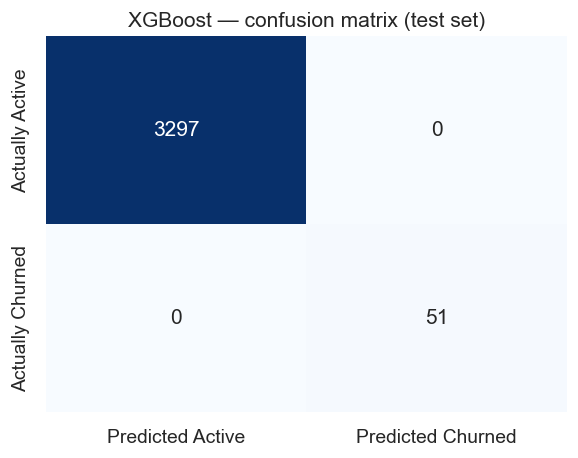

True Negatives  (correctly identified active) : 3297
False Positives (active flagged as churned)   : 0
False Negatives (churned missed by model)     : 0
True Positives  (churned correctly caught)    : 51

Of all actually churned members, model caught: 100.0%


In [11]:
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Active","Predicted Churned"],
            yticklabels=["Actually Active","Actually Churned"],
            ax=ax, cbar=False)
ax.set_title("XGBoost — confusion matrix (test set)")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_confusion_matrix.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly identified active) : {tn}")
print(f"False Positives (active flagged as churned)   : {fp}")
print(f"False Negatives (churned missed by model)     : {fn}")
print(f"True Positives  (churned correctly caught)    : {tp}")
print(f"\nOf all actually churned members, model caught: {tp/(tp+fn)*100:.1f}%")


## 10. Score all members & save

In [12]:
# Assign churn probability score to every member
master["churn_probability"] = xgb_model.predict_proba(master[FEATURE_COLS])[:, 1]
master["churn_probability"] = master["churn_probability"].round(4)

# Risk tier based on probability
master["risk_tier"] = pd.cut(
    master["churn_probability"],
    bins   = [0, 0.2, 0.4, 0.6, 1.0],
    labels = ["Low", "Medium", "High", "Critical"]
)

print("Risk tier distribution:")
print(master["risk_tier"].value_counts().sort_index())
print()
print("Average CLV by risk tier:")
print(master.groupby("risk_tier")["CLV"].mean().round(2))

# Save updated master
master.to_csv(PROC / "master_features.csv", index=False)

# Save model
joblib.dump(xgb_model, PROC / "churn_model.pkl")
joblib.dump(FEATURE_COLS, PROC / "feature_cols.pkl")

print("\nSaved:")
print("  data/processed/master_features.csv  (with churn scores)")
print("  data/processed/churn_model.pkl")
print("  data/processed/feature_cols.pkl")
print()
print("Notebook 03 complete. Proceed to 04_segmentation.ipynb")


Risk tier distribution:
risk_tier
Low         8617
Medium         0
High           0
Critical     257
Name: count, dtype: int64

Average CLV by risk tier:
risk_tier
Low         8104.00
Medium          NaN
High            NaN
Critical    7916.56
Name: CLV, dtype: float64

Saved:
  data/processed/master_features.csv  (with churn scores)
  data/processed/churn_model.pkl
  data/processed/feature_cols.pkl

Notebook 03 complete. Proceed to 04_segmentation.ipynb


In [13]:
print("=== RISK TIER DISTRIBUTION ===")
print(master["risk_tier"].value_counts().sort_index())
print()
print("=== CHURN PROB STATS ===")
print(master["churn_probability"].describe().round(4))
print()
print("=== COLUMNS IN MASTER ===")
print(master.columns.tolist())
print()
print("=== LOYALTY CARD DISTRIBUTION ===")
print(master["Loyalty Card"].value_counts().to_dict())
print()
print("=== PROVINCE TOP 10 ===")
print(master["Province"].value_counts().head(10).to_dict())

=== RISK TIER DISTRIBUTION ===
risk_tier
Low         8617
Medium         0
High           0
Critical     257
Name: count, dtype: int64

=== CHURN PROB STATS ===
count    16737.0000
mean         0.0154
std          0.1229
min          0.0000
25%          0.0000
50%          0.0001
75%          0.0001
max          0.9999
Name: churn_probability, dtype: float64

=== COLUMNS IN MASTER ===
['Loyalty Number', 'total_flights', 'total_distance', 'total_pts_acc', 'total_pts_red', 'total_cost_redeemed', 'months_with_flights', 'total_months_obs', 'recency_months', 'activity_rate', 'redemption_rate', 'h1_monthly_avg', 'h2_monthly_avg', 'activity_trend', 'seasonal_concentration', 'flights_q1', 'flights_q2', 'flights_q3', 'flights_q4', 'avg_flights_last6m', 'Province', 'Gender', 'Education', 'Salary_imputed', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month', 'Cancellation Year', 'churned_formal', 'churned_behavioral', 'enrollment_date', 'tenure_months